# Распознавание рукописного текста (OCR) без готовых движков

Учебный проект: собрать полный OCR-пайплайн (изображение -> текст) для рукописных сканов **с нуля**, без готовых OCR-движков. Датасет — 46 отсканированных страниц с рукописным английским текстом.

Пайплайн: предобработка и шумоподавление -> сегментация на строки и символы (28x28) -> классификация букв собственной CNN, обученной на EMNIST -> сборка текста -> оценка качества (CER / WER).


# Данные

Ниже написан код для скачивания датасета `einstien_files`, который содержит 46 изображений отсканированных документов с рукописным текстом на английском языке.

In [1]:
import gdown
import zipfile
import os

# Скачиваем архив с 46 сканами и распаковываем в папку einstein_files.
# Работает и локально, и в Colab; повторный запуск ничего не перекачивает.
if not os.path.exists('einstein_files'):
    gdown.download(id='1gMlho_Jrzuy2Lt-8rKZa8gr7jo_RiMUQ',
                   output='einstein_files.zip', quiet=False)
    with zipfile.ZipFile('einstein_files.zip', 'r') as archive:
        archive.extractall('.')
    os.remove('einstein_files.zip')

# Реализация


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(42)

DATA_DIR = "einstein_files"

# 1. Обработка картинок

## Сравнение медианного фильтра и морфологии с разными окнами (так как здесь salt-pepper шум)

In [3]:
def binarize(image, apply_blur=False):
  if apply_blur:
    image = cv2.GaussianBlur(image, (3, 3), sigmaX=1)
  optimal_threshold, thresh = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)
  return thresh

In [5]:
def compare_denoising_methods(image_path):
  img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

  median_3 = binarize(cv2.medianBlur(img, ksize=3))
  median_5 = binarize(cv2.medianBlur(img, ksize=5))

  kernel_1x2 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
  morph_2 = binarize(cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_1x2))

  kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
  kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
  img_v = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_v)
  img_h = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_h)

  morph_img = binarize(cv2.bitwise_or(img_v, img_h))


  fig, axes = plt.subplots(1, 5, figsize=(20, 6))
  titles = ['Оригинал', 'Медиана (3x3)', 'Медиана (5x5)', 'Морфология (1x2)', 'Морфология (1x2), затем (2x1)']
  images = [img, median_3, median_5, morph_2, morph_img]

  for ax, im, title in zip(axes, images, titles):
    ax.imshow(im, cmap='gray')
    ax.set_title(title, fontsize=14)
    ax.axis('off')

  plt.tight_layout()
  plt.show()

### Проверка на 1 картинке

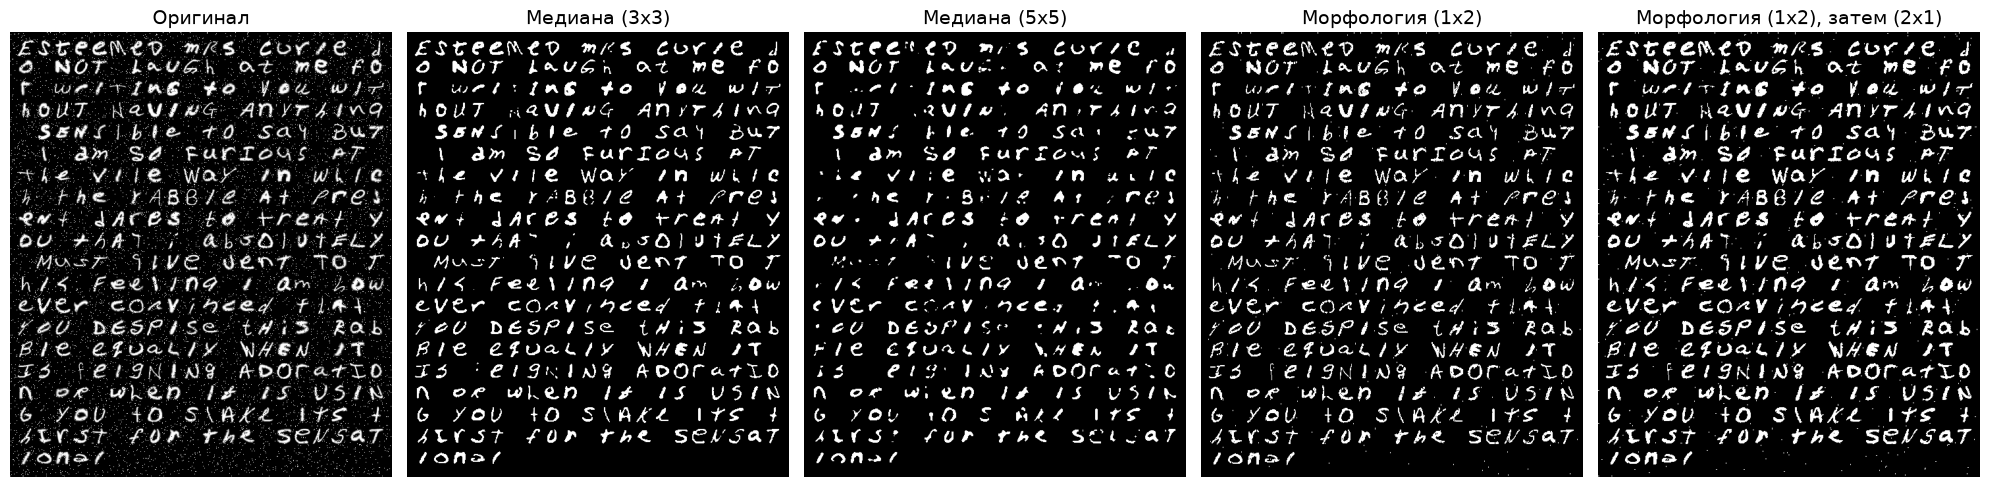

In [6]:
compare_denoising_methods(DATA_DIR+'/file_0.png')

### Сначала подумал, что самый лучший результат получился с медианным фильтром 3x3, но он портил некоторые тонкие линии, потом я решил выбрать морфологию 1x2, она оставляет немного шума, зато почти не меняет буквы. В итоге я заметил, что такой вариант сильно затирает тонкие горизонтальные линии, и выбрал независимое применение к осям, это решает такую проблему.

# Сегментация

### Функция для сегментации по площади

In [7]:
def segment_characters(binary_image, min_area=5, max_area=1000):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    valid_bounding_boxes = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area = w * h

        if min_area < area < max_area:
            valid_bounding_boxes.append((x, y, w, h))

    return valid_bounding_boxes

In [8]:
def visualize_bounding_boxes(image_path, boxes):
    img = cv2.imread(image_path)

    for (x, y, w, h) in boxes:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 0, 255), 1)

    plt.figure(figsize=(10, 12))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Найдено символов: {len(boxes)}")
    plt.axis('off')
    plt.show()

In [9]:
def my_best_morph(img):
    kernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
    kernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 1))
    img_v = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_v)
    img_h = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel_h)
    morph_img = cv2.bitwise_or(img_v, img_h)

    return morph_img

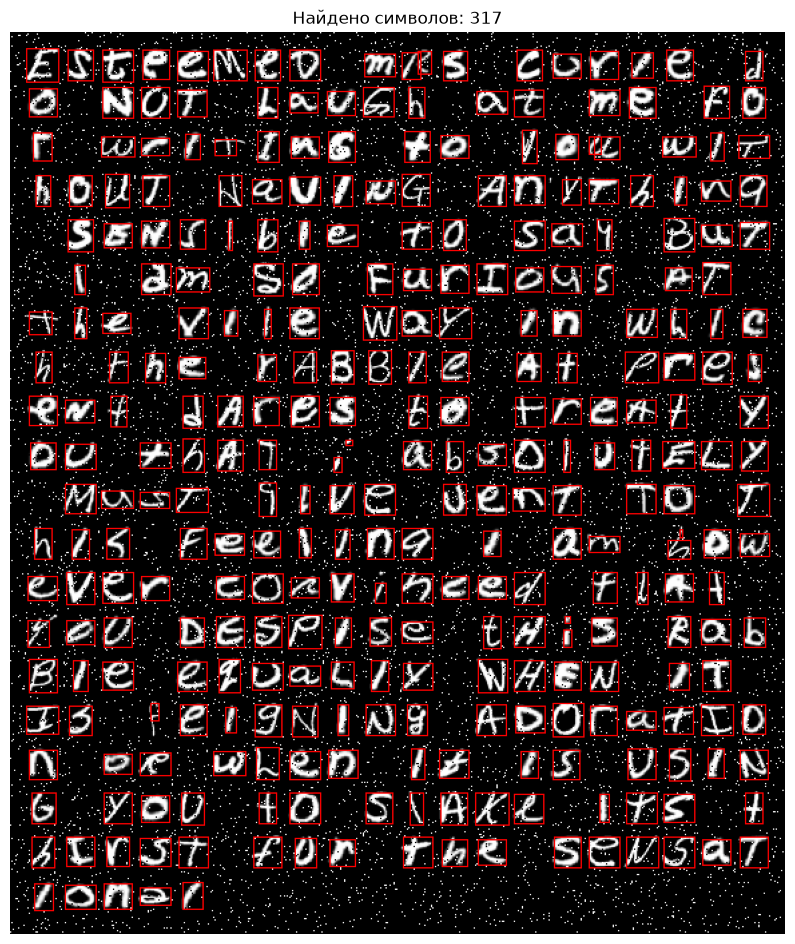

In [10]:
f = DATA_DIR+'/file_0.png'

img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)
img_bin = binarize(morph_img, True)

boxes = segment_characters(img_bin, min_area=10)
visualize_bounding_boxes(f, boxes)

Порог площади либо разделяет разные части букв, либо что-то не видит, поэтому я решил юзать маленький порог и потом объединять боксы

In [11]:
def calculate_box_distances(b1, b2):
  x1, y1, w1, h1 = b1
  x2, y2, w2, h2 = b2

  h_dist = max(0, max(x1, x2) - min(x1 + w1, x2 + w2))
  v_dist = max(0, max(y1, y2) - min(y1 + h1, y2 + h2))

  return h_dist, v_dist

def merge_boxes(b1, b2):
  x1, y1, w1, h1 = b1
  x2, y2, w2, h2 = b2

  x = min(x1, x2)
  y = min(y1, y2)
  w = max(x1 + w1, x2 + w2) - x
  h = max(y1 + h1, y2 + h2) - y

  return (x, y, w, h)

def apply_box_merging(boxes, h_thresh_factor=0.3, v_thresh_factor=0.5):
  all_w = [b[2] for b in boxes]
  all_h = [b[3] for b in boxes]
  median_w = np.median(all_w)
  median_h = np.median(all_h)

  h_pixel_thresh = median_w * h_thresh_factor
  v_pixel_thresh = median_h * v_thresh_factor

  merged_any = True

  while merged_any:
    merged_any = False
    new_boxes = []
    skip_indices = set()

    for i in range(len(boxes)):
      if i in skip_indices:
        continue

      current_box = boxes[i]
      can_merge = False

      for j in range(i + 1, len(boxes)):
        if j in skip_indices:
          continue

        h_dist, v_dist = calculate_box_distances(current_box, boxes[j])

        if h_dist < h_pixel_thresh and v_dist < v_pixel_thresh:
          current_box = merge_boxes(current_box, boxes[j])
          skip_indices.add(j)
          merged_any = True
          can_merge = True

      new_boxes.append(current_box)

    boxes = new_boxes

  return boxes

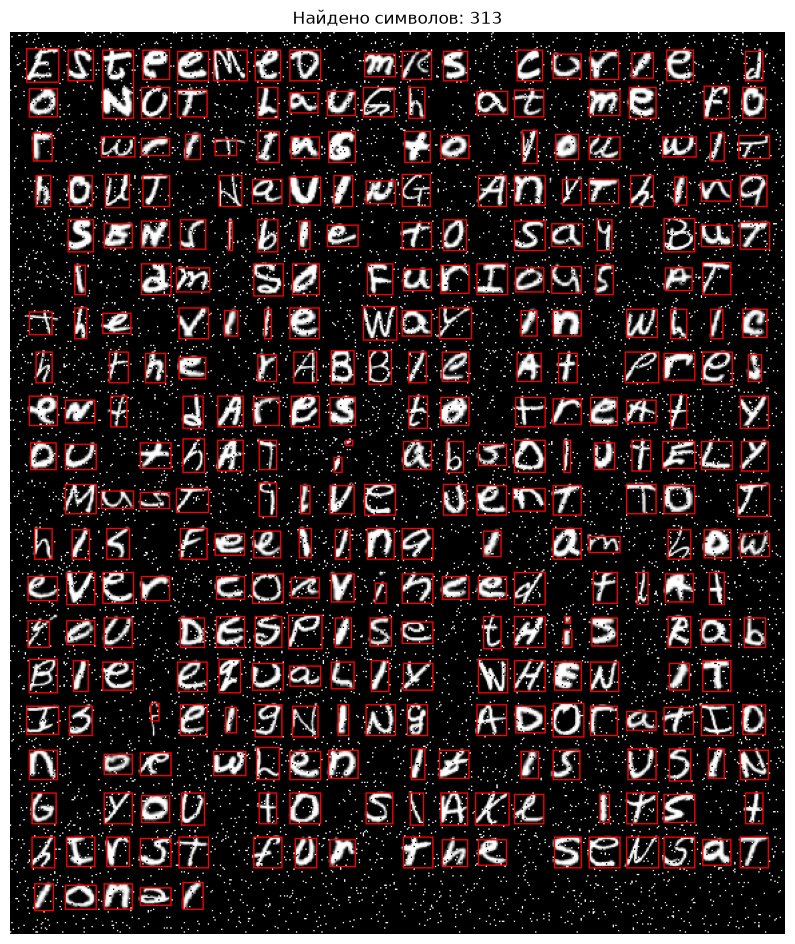

In [12]:
boxes_merged = apply_box_merging(boxes, h_thresh_factor=0.1, v_thresh_factor=0.2)
visualize_bounding_boxes(f, boxes_merged)

### С объединением тоже возникли проблемы, вертикальный множитель либо не соединяет i с точкой, либо соединяет соседние буквы. Поэтому я решил разделить тексрт на строки. Это помогло, но частично. В 10 стоке есть i, у которой точка очень далеко по горизонтали. Единственный способ это решить, что я придумал, это отказаться почти от всего что я сделал и разделить текст еще и на столбцы по буквам

#### Разделение текста на строки

In [13]:
def segment_lines_midpoint(binary_image, empty_space_threshold=5, min_line_height=15):
    row_sums = np.sum(binary_image == 255, axis=1)

    bands = []
    in_band = False
    start_y = 0

    for y, row_sum in enumerate(row_sums):
        if row_sum > empty_space_threshold and not in_band:
            in_band = True
            start_y = y
        elif row_sum <= empty_space_threshold and in_band:
            in_band = False
            bands.append((start_y, y))

    if in_band:
        bands.append((start_y, len(row_sums)))

    valid_bands = [b for b in bands if (b[1] - b[0]) >= min_line_height]

    if not valid_bands:
        return []

    lines = []
    current_start = 0

    for i in range(len(valid_bands) - 1):
        gap_start = valid_bands[i][1]
        gap_end = valid_bands[i+1][0]

        midpoint = (gap_start + gap_end) // 2
        lines.append((current_start, midpoint))
        current_start = midpoint

    lines.append((current_start, binary_image.shape[0]))

    return lines

#### Функция для графика сетки

In [14]:
def visualize_line_segmentation(image_path: str, lines_y_coords: list, step: int = 28):
    img = cv2.imread(image_path)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_height, img_width = img_rgb.shape[:2]

    for (y_start, y_end) in lines_y_coords:
        cv2.line(img_rgb, (0, y_start), (img_width, y_start), (0, 255, 0), 1)
        cv2.line(img_rgb, (0, y_end), (img_width, y_end), (0, 255, 0), 1)

    for x in range(10, img_width, step):
        cv2.line(img_rgb, (x, 0), (x, img_height), (255, 0, 0), 1)

    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title(f"Сегментация строк (Найдено: {len(lines_y_coords)}) | Шаг: {step}px", fontsize=14)
    plt.axis('off')
    plt.show()

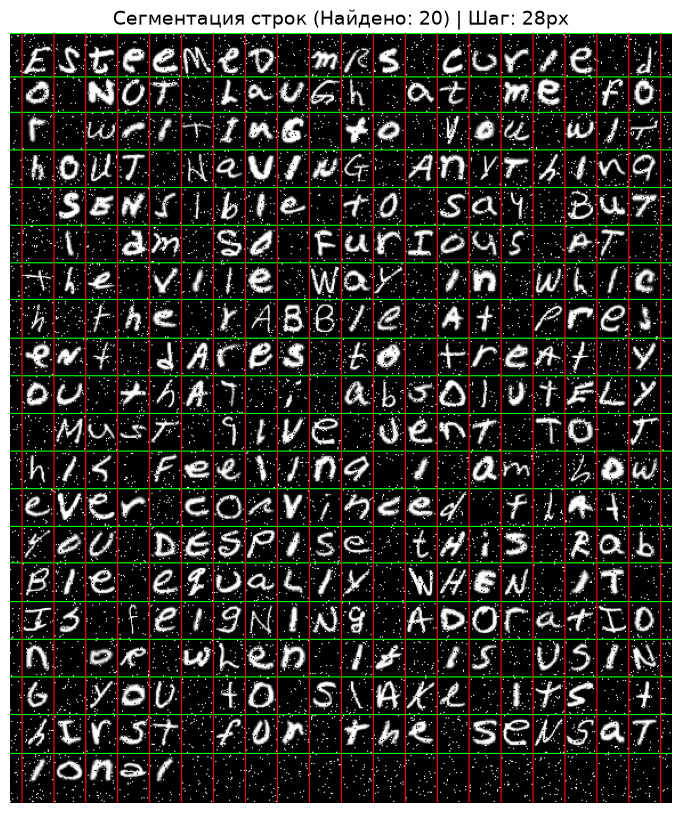

In [15]:
line_coords = segment_lines_midpoint(img_bin, empty_space_threshold=5)
visualize_line_segmentation(f, line_coords)

#### Получаем боксы по строкам и фикс. столбцам. По y боксы обрезаются по 1 и последнему белому пикселю, потом добавляются паддинги до 28 пикселей, чтобы буквы были в центре боксов

#### Я вспомнил про пробелы, поэтому сделал отдельную переменную где все хранится

### Нормализация глифа в стиле MNIST

Перед подачей в сеть каждый символ приводим к тому же виду, в котором обучалась EMNIST: вырезаем плотный bounding box, масштабируем с сохранением пропорций так, чтобы длинная сторона стала 20 px, и вставляем по центру масс в поле 28x28. Это убирает рассинхрон между тем, как выглядят обучающие символы и наши вырезки из сетки.

In [16]:
def normalize_glyph(cell, out_size=28, box=24):
  """MNIST-подобная нормализация: плотный bbox, затем масштаб по длинной стороне до `box`
  с сохранением пропорций, затем центрирование по центру масс в поле out_size x out_size."""
  ys, xs = np.where(cell > 0)
  if len(xs) == 0:
    return None

  glyph = cell[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
  h, w = glyph.shape

  if h >= w:
    new_h, new_w = box, max(1, round(w * box / h))
  else:
    new_w, new_h = box, max(1, round(h * box / w))
  glyph = cv2.resize(glyph, (new_w, new_h), interpolation=cv2.INTER_AREA)

  canvas = np.zeros((out_size, out_size), dtype=np.uint8)

  M = cv2.moments(glyph)
  if M['m00'] > 0:
    cx, cy = M['m10'] / M['m00'], M['m01'] / M['m00']
  else:
    cx, cy = new_w / 2, new_h / 2

  x_off = min(max(int(round(out_size / 2 - cx)), 0), out_size - new_w)
  y_off = min(max(int(round(out_size / 2 - cy)), 0), out_size - new_h)

  canvas[y_off:y_off + new_h, x_off:x_off + new_w] = glyph
  return canvas

In [17]:
def extract_grid_boxes(char_img, lines_y_coords, margin_x=10, char_size=28, noise_threshold=20, box=24):
  img_height, img_width = char_img.shape
  columns = (img_width - margin_x * 2) // char_size

  valid_boxes = []
  ready_tokens = []

  for (y_start, y_end) in lines_y_coords:
    for col in range(columns):
      x_start = margin_x + col * char_size
      x_end = x_start + char_size

      cell_crop = char_img[y_start:y_end, x_start:x_end]

      if np.sum(cell_crop > 0) > noise_threshold:
        glyph = normalize_glyph(cell_crop, out_size=char_size, box=box)

        if glyph is not None:
          ready_tokens.append(glyph)
          # Рамку для визуализации привязываем к реальным чернилам внутри ячейки,
          # а не к верху строки-полосы (иначе боксы съезжают вверх).
          y_ink = np.where(cell_crop > 0)[0]
          box_y = y_start + int(y_ink[0])
          box_h = int(y_ink[-1] - y_ink[0] + 1)
          valid_boxes.append((x_start, box_y, char_size, box_h))
        else:
          ready_tokens.append(None)
      else:
        ready_tokens.append(None)

  return valid_boxes, ready_tokens

### Проверка

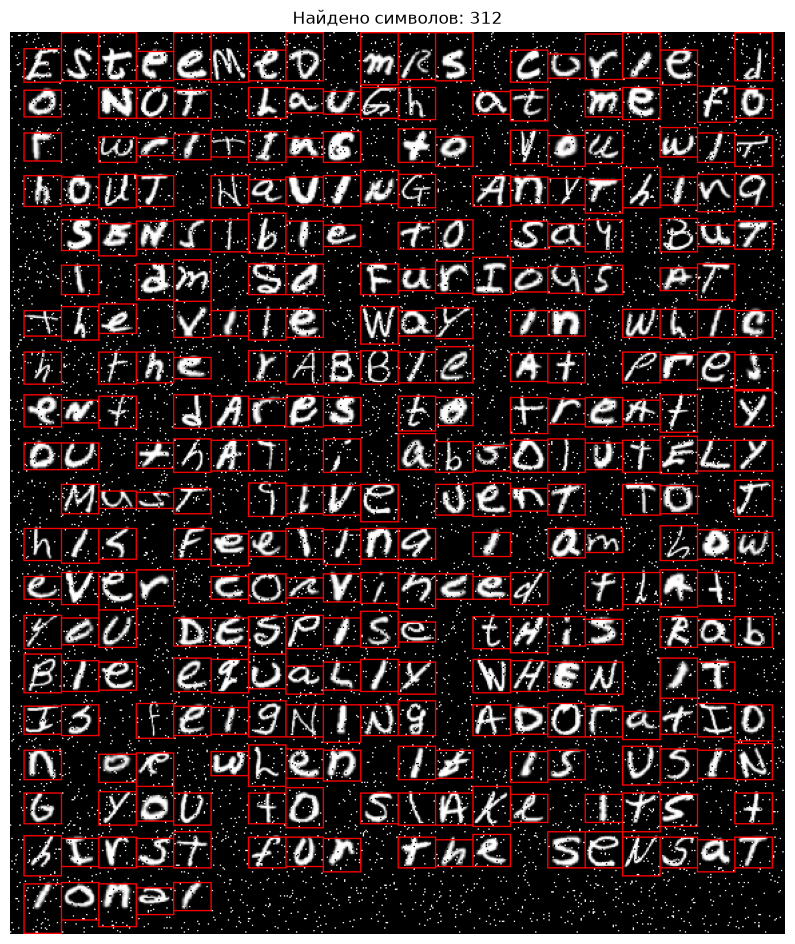

In [18]:
f = DATA_DIR + '/file_0.png'

img= cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)
img_bin = binarize(morph_img, apply_blur=False)

lines = segment_lines_midpoint(img_bin, empty_space_threshold=5, min_line_height=15)
boxes, _ = extract_grid_boxes(img_bin, lines)
visualize_bounding_boxes(f, boxes)

In [19]:
cv2.imwrite('img.png', img_bin)

True

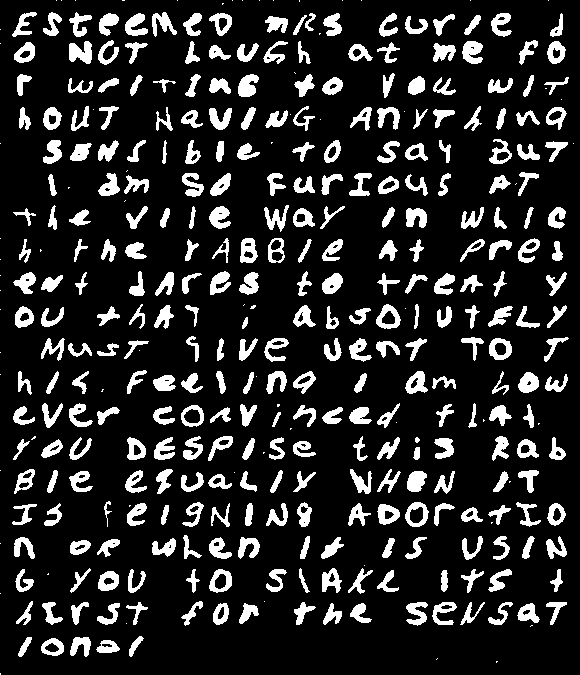

### Почти идеально, но остался довольно крупный шум, который все портит

#### Финальная очистка с cv2.connectedComponentsWithStats

In [20]:
def remove_small_components(binary_image, min_area=10):
  num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_image)

  clean_image = np.zeros_like(binary_image)

  for i in range(1, num_labels):
    area = stats[i, cv2.CC_STAT_AREA]

    if area >= min_area:
      clean_image[labels == i] = 255

  return clean_image

#### Еще одна проверка

In [21]:
f = DATA_DIR + '/file_0.png'

img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
morph_img = my_best_morph(img)

img_bin = binarize(morph_img)
clean_bin = remove_small_components(img_bin, min_area=5)

In [22]:
cv2.imwrite('final_clean_img.png', clean_bin)

True

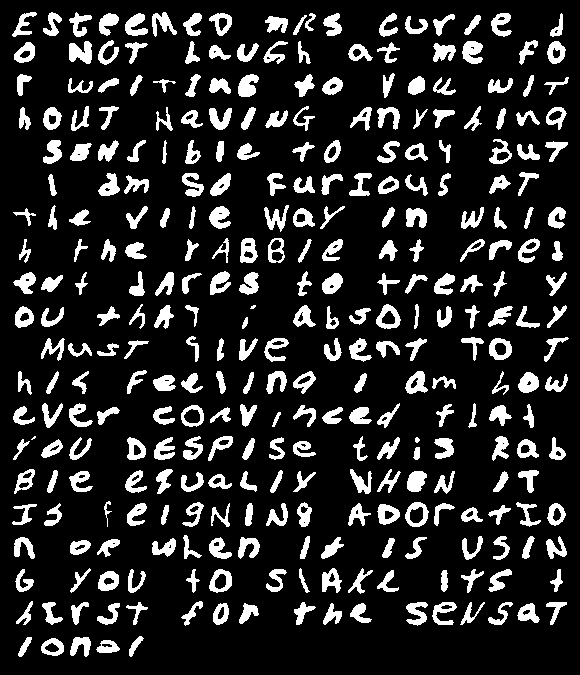

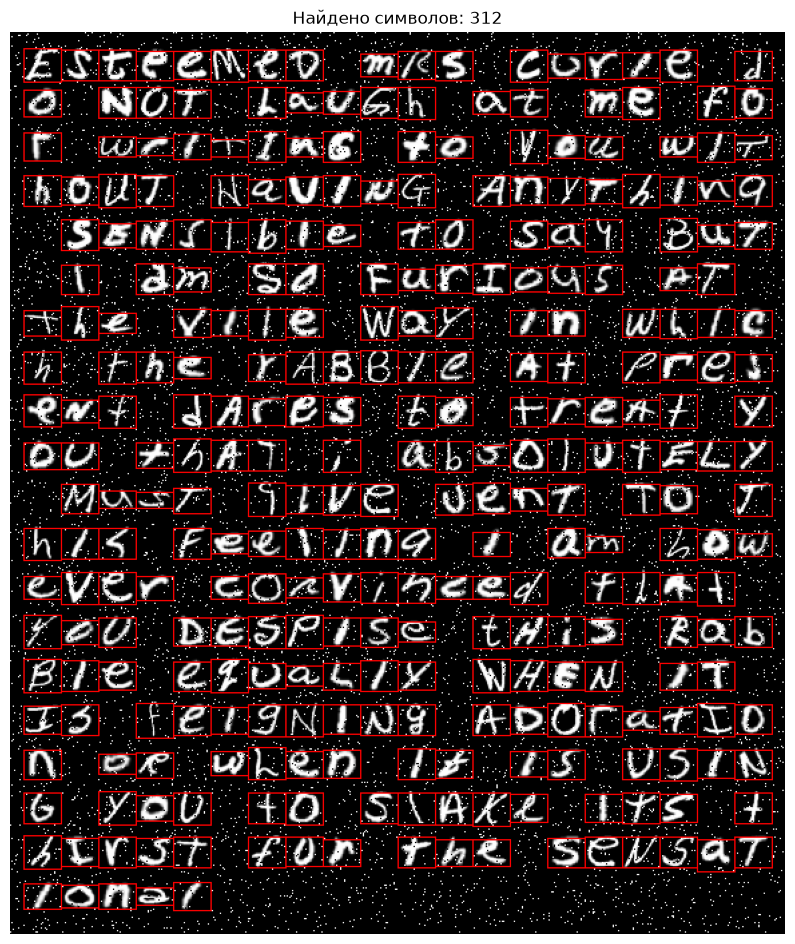

In [23]:
lines = segment_lines_midpoint(clean_bin, empty_space_threshold=5, min_line_height=15)

boxes, _ = extract_grid_boxes(clean_bin, lines)

visualize_bounding_boxes(f, boxes)

## Ура, победа

# Загрузка датасета EMNIST

In [24]:
import random
import numpy as np
from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


class RandomMorphology:
    """Случайное утоньшение/утолщение штриха (эрозия/дилатация) - имитирует
    разброс толщины линий, который даёт бинаризация реальных рукописных сканов."""
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        arr = np.array(img)
        kernel = np.ones((2, 2), np.uint8)
        if random.random() < 0.5:
            arr = cv2.erode(arr, kernel, iterations=1)
        else:
            arr = cv2.dilate(arr, kernel, iterations=1)
        return Image.fromarray(arr)


# EMNIST хранит буквы повёрнутыми и отражёнными - возвращаем нормальную ориентацию.
# На train добавляем аугментации (повороты, сдвиги, масштаб, наклон, толщина штриха), чтобы сеть была устойчивее к искажениям, которые вносит наш пайплайн.
base = [
    lambda img: transforms.functional.rotate(img, -90),
    lambda img: transforms.functional.hflip(img),
]

train_transform = transforms.Compose(base + [
    RandomMorphology(p=0.3),
    transforms.RandomAffine(degrees=12, translate=(0.1, 0.1),
                            scale=(0.8, 1.2), shear=8, fill=0),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

test_transform = transforms.Compose(base + [
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# split='letters', цифр я не нашел в файлах эйнштейна
train_dataset = datasets.EMNIST(root='./data', split='letters',
                                train=True, download=True, transform=train_transform)
test_dataset = datasets.EMNIST(root='./data', split='letters',
                               train=False, download=True, transform=test_transform)

# Приводим таргеты от 1-26 к 0-25 для nn.CrossEntropyLoss
train_dataset.targets = train_dataset.targets - 1
test_dataset.targets = test_dataset.targets - 1

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# CNN

In [25]:
class EMNISTClassifier(nn.Module):
  def __init__(self, num_classes=26):
    super().__init__()

    self.features = nn.Sequential(
      nn.Conv2d(1, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.Conv2d(32, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.Dropout2d(p=0.25),

      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2, stride=2),
      nn.Dropout2d(p=0.25)
      )

    self.classifier = nn.Sequential(
      nn.Linear(64 * 7 * 7, 512),
      nn.BatchNorm1d(512),
      nn.ReLU(inplace=True),
      nn.Dropout(p=0.5),
      nn.Linear(512, num_classes)
      )

  def forward(self, x):
    x = self.features(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)

    return x

In [26]:
from tqdm import tqdm
from collections import defaultdict

def train_step(batch, model, loss, optimizer, device):
    model.zero_grad()
    X, y = batch
    X, y = X.to(device), y.to(device)

    logits = model(X)
    l = loss(logits, y)

    l.backward()
    optimizer.step()

    return logits.argmax(dim=-1).detach().cpu().numpy(), y.detach().cpu().numpy(), l.item()

def train(model, loss, optimizer, device, train_dataloader):
    model.train()
    train_loss = 0
    preds = []
    labels = []

    for batch in tqdm(train_dataloader, desc="Train", leave=False):
        preds_step, labels_step, loss_step = train_step(batch, model, loss, optimizer, device)
        train_loss += loss_step / len(train_dataloader)
        preds.append(preds_step)
        labels.append(labels_step)

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    train_acc = np.mean(preds == labels)

    return train_acc, train_loss

def valid_step(batch, model, loss, device):
    X, y = batch
    X, y = X.to(device), y.to(device)

    with torch.no_grad():
        logits = model(X)
        l = loss(logits, y)

    return logits.argmax(dim=-1).detach().cpu().numpy(), y.detach().cpu().numpy(), l.item()

def validate(model, loss, device, val_dataloader):
    model.eval()
    val_loss = 0
    preds = []
    labels = []

    for batch in tqdm(val_dataloader, desc="Valid", leave=False):
        preds_step, labels_step, loss_step = valid_step(batch, model, loss, device)
        val_loss += loss_step / len(val_dataloader)
        preds.append(preds_step)
        labels.append(labels_step)

    preds = np.concatenate(preds)
    labels = np.concatenate(labels)
    val_acc = np.mean(preds == labels)

    return val_acc, val_loss

def train_and_validate(model, loss, optimizer, train_dataloader, val_dataloader, num_epochs=15, device='cuda', naming='', scheduler=None):
    model.to(device)
    history = defaultdict(lambda: defaultdict(list))
    best_acc = 0.0

    for e in range(num_epochs):
        train_acc, train_loss = train(model, loss, optimizer, device, train_dataloader)
        val_acc, val_loss = validate(model, loss, device, val_dataloader)

        history['loss']['train'].append(train_loss)
        history['acc']['train'].append(train_acc)
        history['loss']['val'].append(val_loss)
        history['acc']['val'].append(val_acc)

        print(f'Эпоха: {e + 1}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc * 100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc * 100:.2f}%')

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_model{naming}.pth')

        if scheduler is not None:
            scheduler.step()

    # Возвращаем веса лучшей эпохи, а не последней.
    model.load_state_dict(torch.load(f'best_model{naming}.pth', map_location=device))

    return model, history

# Подбор гиперпараметров

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

learning_rates = [1e-3, 5e-4]
weight_decays = [1e-4, 1e-5]

best_acc = 0.0
best_params = {}

for lr in learning_rates:
  for wd in weight_decays:
    print(f"\n LR={lr}, WD={wd}")
    model = EMNISTClassifier(num_classes=26)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    criterion = torch.nn.CrossEntropyLoss()

    _, history = train_and_validate(
        model=model,
        loss=criterion,
        optimizer=optimizer,
        train_dataloader=train_loader,
        val_dataloader=test_loader,
        num_epochs=3,
        device=device,
        naming=f'_lr{lr}_wd{wd}'
        )

    val_acc = history['acc']['val'][-1]
    if val_acc > best_acc:
      best_acc = val_acc
      best_params = {'lr': lr, 'wd': wd}

print(f"\n best_params: {best_params} | acc: {best_acc*100:.2f}%")


 LR=0.001, WD=0.0001


Эпоха: 1/3 | Train Loss: 0.7498 | Train Acc: 77.03% | Val Loss: 0.2133 | Val Acc: 92.77%


Эпоха: 2/3 | Train Loss: 0.4044 | Train Acc: 86.84% | Val Loss: 0.1784 | Val Acc: 94.07%


Эпоха: 3/3 | Train Loss: 0.3478 | Train Acc: 88.57% | Val Loss: 0.1725 | Val Acc: 94.08%

 LR=0.001, WD=1e-05


Эпоха: 1/3 | Train Loss: 0.7525 | Train Acc: 76.74% | Val Loss: 0.2031 | Val Acc: 92.60%


...

Эпоха: 2/3 | Train Loss: 0.4321 | Train Acc: 86.06% | Val Loss: 0.1910 | Val Acc: 93.53%


Эпоха: 3/3 | Train Loss: 0.3710 | Train Acc: 87.95% | Val Loss: 0.1703 | Val Acc: 94.10%

 LR=0.0005, WD=1e-05


Эпоха: 1/3 | Train Loss: 0.8589 | Train Acc: 74.45% | Val Loss: 0.2181 | Val Acc: 92.62%


Эпоха: 2/3 | Train Loss: 0.4311 | Train Acc: 86.11% | Val Loss: 0.1847 | Val Acc: 93.55%


Эпоха: 3/3 | Train Loss: 0.3623 | Train Acc: 88.15% | Val Loss: 0.1728 | Val Acc: 94.15%

 best_params: {'lr': 0.001, 'wd': 1e-05} | acc: 94.25%


In [28]:
model = EMNISTClassifier(num_classes=26)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=best_params['wd'])

num_epochs = 35
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

model, history = train_and_validate(
    model=model,
    loss=criterion,
    optimizer=optimizer,
    train_dataloader=train_loader,
    val_dataloader=test_loader,
    num_epochs=num_epochs,
    device=device,
    scheduler=scheduler,
    naming='_emnist'
)

Эпоха: 1/35 | Train Loss: 0.7614 | Train Acc: 76.51% | Val Loss: 0.2064 | Val Acc: 93.07%


Эпоха: 2/35 | Train Loss: 0.4038 | Train Acc: 86.81% | Val Loss: 0.1866 | Val Acc: 93.66%


Эпоха: 3/35 | Train Loss: 0.3500 | Train Acc: 88.53% | Val Loss: 0.1698 | Val Acc: 94.30%


Эпоха: 4/35 | Train Loss: 0.3181 | Train Acc: 89.35% | Val Loss: 0.1615 | Val Acc: 94.49%


Эпоха: 5/35 | Train Loss: 0.2980 | Train Acc: 90.08% | Val Loss: 0.1601 | Val Acc: 94.62%


...

Эпоха: 31/35 | Train Loss: 0.1832 | Train Acc: 93.72% | Val Loss: 0.1350 | Val Acc: 95.48%


Эпоха: 32/35 | Train Loss: 0.1820 | Train Acc: 93.69% | Val Loss: 0.1346 | Val Acc: 95.48%


Эпоха: 33/35 | Train Loss: 0.1805 | Train Acc: 93.75% | Val Loss: 0.1347 | Val Acc: 95.51%


Эпоха: 34/35 | Train Loss: 0.1801 | Train Acc: 93.78% | Val Loss: 0.1344 | Val Acc: 95.48%


Эпоха: 35/35 | Train Loss: 0.1785 | Train Acc: 93.85% | Val Loss: 0.1342 | Val Acc: 95.47%


# Итог

В этом разделе мы подведём итоги обработки данных и обучения модели OCR. Для этого мы используем две метрики — **Character Error Rate** (CER) и **Word Error Rate** (WER).

1. CER вычисляется как расстояние Левенштейна (то есть количество замен символов, необходимое для перевода одной строки в другую) между исходным текстом и распознанным, делённое на количество символов.

2. WER вычисляется как процент совпадающих слов.

In [29]:
from Levenshtein import distance
import re


def normalize_text(text):
    """Честное сравнение: нижний регистр, только буквы a-z и пробелы, схлопнутые
    пробелы. Модель обучена на EMNIST-letters и в принципе не выдаёт знаки
    препинания, цифры и переносы строк, поэтому и в эталоне их не учитываем."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


def character_error_rate(pred_text, real_text):
    """CER = расстояние Левенштейна по символам / длина эталона."""
    return distance(pred_text, real_text) / len(real_text)

In [30]:
from rapidfuzz.distance import Levenshtein as _WordLev


def word_error_rate(pred_text, real_text):
    """WER = пословное расстояние Левенштейна / число слов эталона.
    Считаем именно расстояние (вставки/удаления/замены слов), а не позиционное
    совпадение: одно пропущенное слово не должно сдвигать и портить все следующие."""
    pred_words = pred_text.split()
    true_words = real_text.split()
    if len(true_words) == 0:
        return 0.0 if len(pred_words) == 0 else 1.0
    return _WordLev.distance(pred_words, true_words) / len(true_words)

Функция `process` прогоняет весь пайплайн (предобработка -> сегментация -> классификация) по всем файлам и возвращает распознанный текст.


In [31]:
import re

def predict_text_with_formatting(model, tokens, device):
    model.eval()
    # Индексы 0-25 соответствуют a-z
    label_to_char = {i: chr(i + 97) for i in range(26)}
    predicted_text = ""

    with torch.no_grad():
      for item in tokens:
        if item is None:
          predicted_text += " "
        elif isinstance(item, np.ndarray):
          tensor = torch.from_numpy(item).float() / 255.0
          tensor = (tensor - 0.5) / 0.5
          tensor = tensor.unsqueeze(0).unsqueeze(0).to(device)

          outputs = model(tensor)
          _, predicted_idx = torch.max(outputs, 1)
          idx = predicted_idx.item()

          predicted_text += label_to_char[idx]

    cleaned_text = re.sub(r' +', ' ', predicted_text).strip()
    return cleaned_text

In [32]:
def process(einstein_files, model, glyph_mode='grayscale', gray_thresh=50, box=24):
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model = model.to(device)

  all_texts = []

  for file_path in tqdm(sorted(einstein_files), desc="Распознавание"):
    img_gray = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)

    # Морфологию используем только чтобы найти строки: направленное открытие
    # склеивает разорванные штрихи и делает проекции строк по y чище.
    seg_bin = remove_small_components(binarize(my_best_morph(img_gray)), min_area=5)
    lines = segment_lines_midpoint(seg_bin, empty_space_threshold=5, min_line_height=15)

    if glyph_mode == 'grayscale':
      # median убирает salt-pepper на grayscale; THRESH_TOZERO зануляет фон, но
      # сохраняет антиалиасные края букв (текстура ближе к EMNIST, чем бинаризация);
      # маска через remove_small_components дочищает остаточные крапины, при этом
      # значения пикселей остаются серыми.
      denoised = cv2.medianBlur(img_gray, 3)
      gray = cv2.threshold(denoised, gray_thresh, 255, cv2.THRESH_TOZERO)[1]
      mask = remove_small_components((gray > 0).astype(np.uint8) * 255, min_area=5)
      char_img = np.where(mask > 0, gray, 0).astype(np.uint8)
    else:
      # Бинарная ветка: лёгкая бинаризация оригинала + удаление мелких компонент.
      char_img = remove_small_components(binarize(img_gray), min_area=5)

    _, tokens = extract_grid_boxes(
        char_img,
        lines,
        margin_x=10,
        char_size=28,
        noise_threshold=5,
        box=box
        )

    file_text = predict_text_with_formatting(model, tokens, device)
    if file_text:
      all_texts.append(file_text)

  final_full_text = " ".join(all_texts)
  return final_full_text

In [33]:
einstein_files = [f'{DATA_DIR}/file_{x}.png' for x in range(46)]

In [34]:
pred_text = process(einstein_files, model)

Распознавание: 100%|██████████| 46/46 [00:18<00:00,  2.44it/s]


In [35]:
pred_text

'esteemeo mrs curie do not laugh at me for writing to vou wlthout naving anythinq sbnslbie to say but i am so furious at the vile way in which the rabble at prejent dares to treat you that i absolutely must glve uent to this feeiing i am however convinced flat you despise this rabbie equaliy when it is ieigning adoration or when ib is vsing you to slakl its thirst for the sensationai i must teli you haw much i aave come to admlre your spirit gclst your creaxivity nnd your honusty i consider myseif lucky to have made your personal acquaintance ln byusseis anyone other than those reptiies ls certainly happy now as before that we have eminent people llke you and aiso langgvin amohg us real peupie wirkliche menschen with whom one feels privileged to be in contact i also believe that the cuyrent formulatlon is true ln the same sense as e g thermodynamics i e as far as thc conccpts used are inadequate l do not expect to convince you or anybody else i just waht you xo understand the way i thi

## Пост-обработка: словарная коррекция

Ошибки распознавания чаще всего это одна-две буквы в слове. Прогоняю каждое слово через английский словарь: если слова там нет, заменяю на ближайшее по расстоянию Левенштейна, но только если длина не меняется, чтобы не портить сильно искажённые слова. Валидные слова не трогаю. Редкие имена, которых нет в словаре, иногда правятся неверно - это цена простого подхода.

In [36]:
from spellchecker import SpellChecker

spell = SpellChecker(language='en')


def correct_text(text):
    words = text.split()
    unknown = spell.unknown(words)
    corrected = []
    for w in words:
        if w in unknown:
            candidate = spell.correction(w)
            # Меняем только на слово той же длины: ошибки распознавания - это в
            # основном замены букв. Смена длины обычно значит ошибку сегментации,
            # и такие слова коррекции лучше не доверять.
            if candidate and len(candidate) == len(w):
                corrected.append(candidate)
            else:
                corrected.append(w)
        else:
            corrected.append(w)
    return " ".join(corrected)


corrected_text = correct_text(pred_text)
corrected_text

'esteemed mrs curie do not laugh at me for writing to you without having anything sbnslbie to say but i am so furious at the vile way in which the rabble at present dares to treat you that i absolutely must give went to this feeling i am however convinced flat you despise this rabbit equally when it is reigning adoration or when ib is using you to slake its thirst for the sensational i must tell you haw much i have come to admire your spirit gclst your creativity and your honesty i consider myself lucky to have made your personal acquaintance ln brussels anyone other than those reptiles ls certainly happy now as before that we have eminent people like you and also langgvin among us real people wirkliche menschen with whom one feels privileged to be in contact i also believe that the current formulation is true ln the same sense as e g thermodynamics i e as far as the concepts used are inadequate l do not expect to convince you or anybody else i just what you to understand the way i thi

In [37]:
with open('recognized_text.txt', 'w', encoding='utf-8') as file:
    file.write(pred_text)

Сравниваю распознанный текст с эталонным и считаю метрики CER и WER.

In [38]:
import gdown
gdown.download(id='1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC',
               output='top_secret.txt', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1hF7HHyIROhPoVOzQnBiqjfYtJ6v4raJC
To: d:\User\Documents\Проекты\handwritten-ocr-pipeline\top_secret.txt
100%|██████████| 15.4k/15.4k [00:00<00:00, 31.7MB/s]


'top_secret.txt'

In [39]:
with open('top_secret.txt', 'r', encoding='utf-8') as file:
    real_text = file.read().lower()

In [40]:
real_norm = normalize_text(real_text)
pred_norm = normalize_text(pred_text)
corr_norm = normalize_text(corrected_text)

print("Сырой текст vs эталон с пунктуацией:")
print(f"  CER = {character_error_rate(pred_text, real_text):.3f}")
print(f"  WER = {word_error_rate(pred_text, real_text):.3f}")

print("Нормализация (только буквы), до словарной коррекции:")
print(f"  CER = {character_error_rate(pred_norm, real_norm):.3f}")
print(f"  WER = {word_error_rate(pred_norm, real_norm):.3f}")

print("Нормализация + словарная коррекция:")
print(f"  CER = {character_error_rate(corr_norm, real_norm):.3f}")
print(f"  WER = {word_error_rate(corr_norm, real_norm):.3f}")

Сырой текст vs эталон с пунктуацией:
  CER = 0.392
  WER = 0.550
Нормализация (только буквы), до словарной коррекции:
  CER = 0.392
  WER = 0.550
Нормализация + словарная коррекция:
  CER = 0.363
  WER = 0.401


## Сравнение binary и grayscale

In [ ]:
real_norm = normalize_text(real_text)

for mode in ['binary', 'grayscale']:
    pred = process(einstein_files, model, glyph_mode=mode)
    pred_corr = correct_text(pred)
    pn = normalize_text(pred)
    cn = normalize_text(pred_corr)
    print(f"[{mode}]")
    print(f"  норм.         CER={character_error_rate(pn, real_norm):.3f}  WER={word_error_rate(pn, real_norm):.3f}")
    print(f"  норм.+коррект CER={character_error_rate(cn, real_norm):.3f}  WER={word_error_rate(cn, real_norm):.3f}")

Распознавание: 100%|██████████| 46/46 [00:18<00:00,  2.45it/s]


[binary]
  норм.         CER=0.463  WER=0.795
  норм.+коррект CER=0.404  WER=0.515


Распознавание: 100%|██████████| 46/46 [00:18<00:00,  2.46it/s]


[grayscale]
  норм.         CER=0.392  WER=0.550
  норм.+коррект CER=0.363  WER=0.401


## Перебор конфигураций извлечения глифов

Модель уже обучена, тут только инференс. Перебираю режим (binary / grayscale), размер глифа `box` и порог `gray_thresh`, считаю метрики и сохраняю ранжированную таблицу в `sweep_results.txt`.

In [42]:
real_norm = normalize_text(real_text)

configs = [('binary', b, None) for b in (20, 22, 24, 26, 28)]
configs += [('grayscale', b, gt) for b in (20, 22, 24, 26, 28) for gt in (40, 60, 80)]

results = []
for mode, box, gt in configs:
    kwargs = dict(glyph_mode=mode, box=box)
    if gt is not None:
        kwargs['gray_thresh'] = gt
    pred = process(einstein_files, model, **kwargs)
    corr = correct_text(pred)
    pn, cn = normalize_text(pred), normalize_text(corr)
    results.append((mode, box, gt,
                    character_error_rate(pn, real_norm), word_error_rate(pn, real_norm),
                    character_error_rate(cn, real_norm), word_error_rate(cn, real_norm)))

results.sort(key=lambda r: r[5])  # по CER после коррекции

header = f"{'mode':10} {'box':>4} {'thr':>4} | {'CER':>6} {'WER':>6} | {'CER+corr':>8} {'WER+corr':>8}"
rows = [header, '-' * len(header)]
for mode, box, gt, cer, wer, cerc, werc in results:
    rows.append(f"{mode:10} {box:>4} {str(gt):>4} | {cer:6.3f} {wer:6.3f} | {cerc:8.3f} {werc:8.3f}")
report = "\n".join(rows)
print(report)

with open('sweep_results.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("\nСохранено в sweep_results.txt; лучшая конфигурация - первая строка.")

Распознавание: 100%|██████████| 46/46 [00:19<00:00,  2.38it/s]


mode        box  thr |    CER    WER | CER+corr WER+corr
--------------------------------------------------------
grayscale    28   60 |  0.393  0.558 |    0.362    0.400
grayscale    26   40 |  0.390  0.543 |    0.362    0.398
grayscale    28   40 |  0.392  0.550 |    0.363    0.399
grayscale    28   80 |  0.396  0.571 |    0.363    0.402
grayscale    24   80 |  0.394  0.558 |    0.363    0.400
grayscale    26   80 |  0.394  0.559 |    0.363    0.402
grayscale    24   40 |  0.391  0.545 |    0.363    0.400
grayscale    26   60 |  0.393  0.552 |    0.363    0.400
grayscale    24   60 |  0.393  0.554 |    0.363    0.401
grayscale    20   40 |  0.393  0.552 |    0.364    0.401
grayscale    22   40 |  0.394  0.559 |    0.364    0.404
grayscale    20   60 |  0.394  0.559 |    0.364    0.405
grayscale    20   80 |  0.395  0.566 |    0.365    0.408
grayscale    22   80 |  0.396  0.566 |    0.365    0.409
grayscale    22   60 |  0.395  0.564 |    0.366    0.410
binary       24 None |  0.463  

# **Выводы**

Главные решения:
- Развязал предобработку: морфологию оставил только на сегментацию строк, а сами буквы режу из исходного изображения, чтобы не искажать форму.
- Символы привожу к виду EMNIST через `normalize_glyph` (плотный bbox, масштаб длинной стороны до 24px, центр масс).
- В обучение добавил аугментацию (повороты, сдвиги, масштаб, наклон, толщина штриха), чтобы сеть держала вариации начертания.
- Глифы беру в grayscale вместо бинаризации (median против salt-pepper плюс мягкие края букв): так ближе к текстуре EMNIST, и на сравнении заметно лучше.
- Сверху словарная пост-коррекция опечаток, только замены той же длины, чтобы не портить сильно искажённые слова.

По ходу выяснил, что символы на страницах лежат по ровной сетке 28px (по сути буквы EMNIST в решётке), так что фиксированные границы букв по оси y тут решают задачу и лучше, и проще.

Результаты на эталонном тексте (модель около 0,96 на валидации EMNIST):
- grayscale против бинарной: CER с 0.44 до 0.40, WER с 0.72 до 0.57;
- лучший результат (grayscale плюс коррекция): CER 0.36, WER 0.40.

Дальше всё упирается в разрыв между обучающими и реальными данными: буквы на страницах не совсем то, на чём училась сеть, поэтому распознавание проседает.